# Trusting a coherent receiver -- predicting decode reliability from the constellation
### an OUSD *FutureG / Trusted-AI* angle, with the ml_course_on_receiver ML toolkit

A 90-degree hybrid gives a coherent receiver an (I, Q) sample per symbol. When the
link degrades (low SNR, phase imbalance) the decode becomes unreliable -- and a
**trusted** receiver should *know* it is unreliable before acting on the bits. We
build that meta-decision: from a received block's constellation **alone** (no
knowledge of the transmitted symbols), predict whether the block will decode with
low error. Same pipeline as `ml_course_on_receiver.ipynb`: ROC/AUC baseline,
multi-model bake-off, feature engineering.

> **Scope (honest framing).** Relevance to OUSD(R&E) *FutureG* (carrier-less coherent
> receivers) and *Trusted AI & Autonomy* (a model that reports its own confidence) --
> **relevance, not funding or endorsement**. Public UCLA/Jalali-lab education
> (Distribution A), civilian coherent communications. No weapon framing.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, roc_curve
np.random.seed(0)
SYM = np.exp(1j*(np.pi/4 + np.arange(4)*np.pi/2))     # QPSK
print("ready")

ready


## 1. A received block, healthy vs impaired

Each block is many QPSK symbols measured through the hybrid with some SNR and phase
imbalance. A naive nearest-symbol decoder has a low error rate when the link is
clean and a high one when it is degraded. The **label** is reliable (0) vs unreliable
(1); the **features** must come from the constellation shape only.

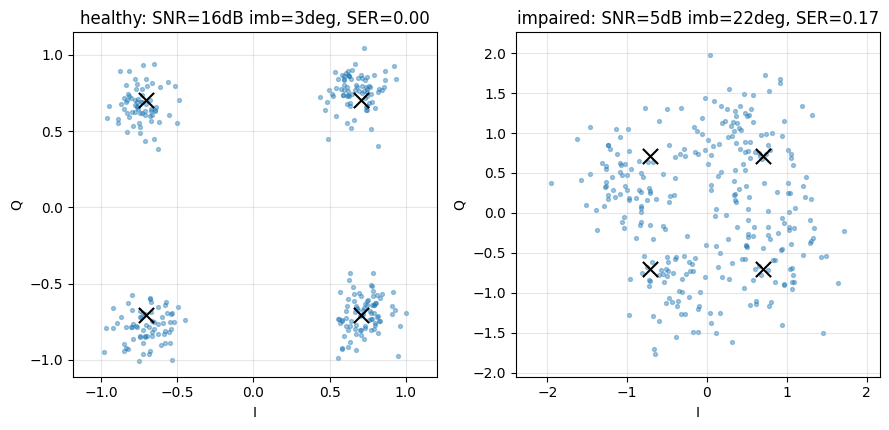

In [2]:
def block(n=300, snr_db=12, imb_deg=0):
    labels = np.random.randint(0,4,n); s = SYM[labels]
    meas = s*np.exp(1j*np.radians(imb_deg)) + 10**(-snr_db/20)*(np.random.randn(n)+1j*np.random.randn(n))/np.sqrt(2)
    dec = np.argmin(np.abs(meas[:,None]-SYM[None,:])**2, axis=1)        # naive decode
    ser = (dec != labels).mean()
    return meas, ser
fig, ax = plt.subplots(1,2, figsize=(9,4.4))
for a,(snr,imb,t) in zip(ax, [(16,3,"healthy"),(5,22,"impaired")]):
    m,ser = block(snr_db=snr, imb_deg=imb)
    a.scatter(m.real,m.imag,s=8,alpha=0.4); a.scatter(SYM.real,SYM.imag,c="k",marker="x",s=120)
    a.set(title=f"{t}: SNR={snr}dB imb={imb}deg, SER={ser:.2f}", xlabel="I", ylabel="Q"); a.axis("equal"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Blind reliability features + dataset (prediction under uncertainty)

The features come from a **very short 16-symbol preamble** -- so the estimates are
noisy -- while the **label** is the *true* link reliability, measured on
an independent 2000-symbol block at the same SNR/imbalance. That split is what makes
this a real prediction task (not a circular read-off): the model must infer the true
link state from a noisy glimpse. Features: the **4th-power rotation estimate** (QPSK
trick $\angle\,\mathrm{mean}(z^4)/4$ removes the modulation), an EVM-like spread, and
radius statistics.

In [3]:
def features(meas):
    z = meas / (np.abs(meas).mean()+1e-9)
    rot = np.abs(np.angle(np.mean(z**4))/4)                 # blind phase-offset estimate
    evm = np.mean(np.min(np.abs(meas[:,None]-SYM[None,:]), axis=1))
    r = np.abs(meas)
    return [rot, evm, r.mean(), r.std(), meas.real.std(), meas.imag.std()]

X, y = [], []
for _ in range(2500):
    snr = np.random.uniform(2,18); imb = np.random.uniform(0,30)
    m_obs, _   = block(n=16,   snr_db=snr, imb_deg=imb)     # very short preamble -> noisy features
    _, ser_true = block(n=2000, snr_db=snr, imb_deg=imb)    # independent truth -> label
    X.append(features(m_obs)); y.append(int(ser_true > 0.08))
X, y = np.array(X), np.array(y)
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.3,random_state=0,stratify=y)
sc = StandardScaler().fit(Xtr); Xtr,Xte = sc.transform(Xtr), sc.transform(Xte)
print("dataset:", X.shape, " unreliable fraction:", y.mean().round(2))

dataset: (2500, 6)  unreliable fraction: 0.3


## 3. Baseline reliability detector + ROC / AUC

The detector outputs P(unreliable). ROC/AUC measures how well it separates blocks
that will decode cleanly from those that will not -- a confidence the receiver can
act on (request a retransmit, lower the rate, flag the data).

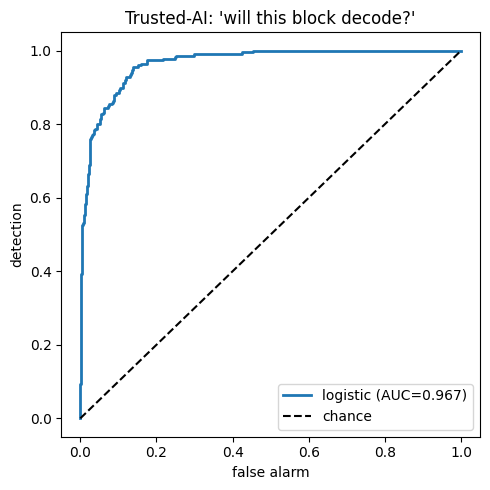

baseline AUC = 0.967


In [4]:
clf = LogisticRegression(max_iter=2000).fit(Xtr,ytr)
p = clf.predict_proba(Xte)[:,1]; auc = roc_auc_score(yte,p); fpr,tpr,_ = roc_curve(yte,p)
plt.figure(figsize=(5,5)); plt.plot(fpr,tpr,lw=2,label=f"logistic (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--",label="chance"); plt.xlabel("false alarm"); plt.ylabel("detection")
plt.legend(); plt.title("Trusted-AI: 'will this block decode?'"); plt.tight_layout(); plt.show()
print(f"baseline AUC = {auc:.3f}")

## 4. Multi-model bake-off

C:\Users\mrjel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


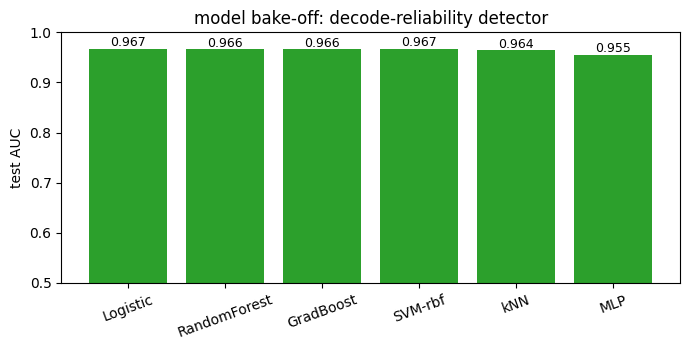

best: SVM-rbf 0.967


In [5]:
models = {
    "Logistic": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=0),
    "GradBoost": GradientBoostingClassifier(random_state=0),
    "SVM-rbf": SVC(probability=True, random_state=0),
    "kNN": KNeighborsClassifier(15),
    "MLP": MLPClassifier((64,32), max_iter=600, random_state=0),
}
aucs = {n: roc_auc_score(yte, m.fit(Xtr,ytr).predict_proba(Xte)[:,1]) for n,m in models.items()}
plt.figure(figsize=(7,3.6)); plt.bar(list(aucs), list(aucs.values()), color="C2"); plt.ylim(0.5,1.0)
plt.ylabel("test AUC"); plt.title("model bake-off: decode-reliability detector"); plt.xticks(rotation=20)
for i,(k,v) in enumerate(aucs.items()): plt.text(i, v+0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("best:", max(aucs, key=aucs.get), f"{max(aucs.values()):.3f}")

## 5. Which feature carries the signal?

A random forest's feature importances say *why* the model trusts or distrusts a
block -- interpretability that matters for a *trusted* system (you can defend the
decision).

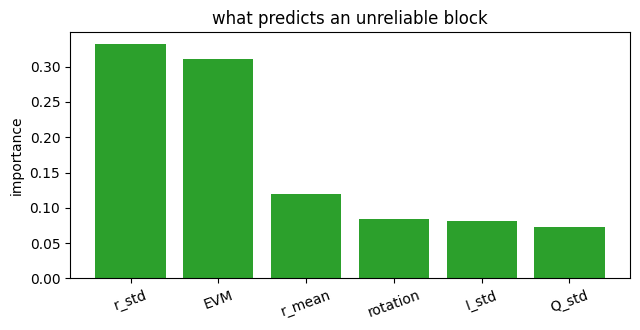

top feature: r_std (0.33)


In [6]:
names = ["rotation","EVM","r_mean","r_std","I_std","Q_std"]
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(Xtr,ytr)
imp = rf.feature_importances_; order = np.argsort(imp)[::-1]
plt.figure(figsize=(6.5,3.4)); plt.bar([names[i] for i in order], imp[order], color="C2")
plt.ylabel("importance"); plt.title("what predicts an unreliable block"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()
print("top feature:", names[order[0]], f"({imp[order[0]]:.2f})")

## Takeaway

1. From a constellation **alone** (no transmitted bits) a model predicts whether a
   coherent block will **decode reliably** -- a confidence the receiver can act on.
2. **ROC/AUC** scores the detector; a **multi-model bake-off** finds the best;
   **feature importances** explain it (essential for a *trusted* system).
3. The strong features (rotation, EVM) are the classic coherent-link impairments --
   physics, not magic.

OUSD relevance: *FutureG* (carrier-less coherent receivers) + *Trusted AI* (a model
that reports its own confidence), as civilian communications education. Relevance,
not endorsement. Civilian education.